In [25]:
import cupy as cp
import time
import matplotlib.pyplot as plt

In [26]:
SEED = 42
cp.random.seed(SEED)

BOX_LENGHT = 1
SPACE_DIM = 3

In [27]:
def compute_distance_square_matrix_cp(positions: cp.ndarray) -> cp.ndarray:
    r2 = cp.sum(positions * positions, axis=1)
    D2 = r2[:, None] + r2[None, :] - 2 * (positions @ positions.T)
    cp.fill_diagonal(D2, cp.inf) # Remove self interactions
    return D2

def compute_coulomb_energy_cp(charges: cp.ndarray, D2: cp.ndarray) -> cp.float32:
    energy = 0.5 * cp.sum((charges[:, None] * charges[None, :]) / cp.sqrt(D2))
    return energy

def compute_lennard_jones_energy_cp(D2: cp.ndarray) -> cp.float32:
    D8 = cp.power(D2, 4)
    energy = cp.sum(1 / D8)
    return energy

def compute_potential_energy_cp(positions: cp.ndarray, charges: cp.ndarray) -> cp.float32:
    D2 = compute_distance_square_matrix_cp(positions)
    energy_coulomb = compute_coulomb_energy_cp(charges, D2)
    energy_lj = compute_lennard_jones_energy_cp(D2)
    return energy_coulomb + energy_lj


In [28]:
def create_particles_cp(N_PARTICLES):

    positions = cp.random.uniform(0, BOX_LENGHT, size=(N_PARTICLES, SPACE_DIM))
    charge = cp.sign(cp.random.uniform(-1.0, 1.0, size=N_PARTICLES))

    return positions, charge

In [29]:
N = [100, 1000, 1500, 2000, 3000, 4000, 10000]

for N_PARTICLES in N:

    positions, charges = create_particles_cp(N_PARTICLES)

    # sincronize GPU
    cp.cuda.Stream.null.synchronize()
    start = time.time()

    energy = compute_potential_energy_cp(positions, charges)

    cp.cuda.Stream.null.synchronize()
    end = time.time()

    print(f"N_particles = {N_PARTICLES}")
    print(f"Time GPU: {(end - start)*1000:.0f} ms\n")

N_particles = 100
Time GPU: 3 ms

N_particles = 1000
Time GPU: 13 ms

N_particles = 1500
Time GPU: 28 ms

N_particles = 2000
Time GPU: 50 ms

N_particles = 3000
Time GPU: 118 ms

N_particles = 4000
Time GPU: 209 ms

N_particles = 10000
Time GPU: 1362 ms



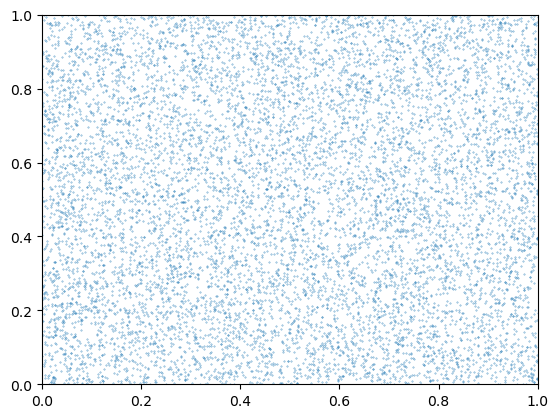

In [30]:
plt.scatter(cp.asnumpy(positions[:,0]), cp.asnumpy(positions[:,1]), s = 0.1, alpha=0.8)

plt.xlim([0,1])
plt.ylim([0,1])

plt.show()